In [1]:
!gdown --folder https://drive.google.com/drive/folders/1hmPlvhIHvMoQBYNKO3Hu2eZAaAVZ5-oo

Processing file 1za8beqkIYs2bhcFCGiSUn53QQdWqLdDw eyes_closed_output.zip
Processing file 160h1t_RqEiNt5ILMpH6ttmSIxbPvT7VZ eyes_opened_output.zip


Retrieving folder contents
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1za8beqkIYs2bhcFCGiSUn53QQdWqLdDw
To: c:\code\Study\Deep-Learning\final-project\DDD-KU\scripts\eye_dataset\eyes_closed_output.zip

  0%|          | 0.00/19.0M [00:00<?, ?B/s]
  3%|▎         | 524k/19.0M [00:00<00:04, 4.33MB/s]
  8%|▊         | 1.57M/19.0M [00:00<00:02, 7.50MB/s]
 14%|█▍        | 2.62M/19.0M [00:00<00:01, 8.45MB/s]
 19%|█▉        | 3.67M/19.0M [00:00<00:01, 9.18MB/s]
 25%|██▍       | 4.72M/19.0M [00:00<00:01, 9.57MB/s]
 30%|███       | 5.77M/19.0M [00:00<00:01, 9.82MB/s]
 39%|███▊      | 7.34M/19.0M [00:00<00:01, 9.97MB/s]
 47%|████▋     | 8.91M/19.0M [00:00<00:00, 10.9MB/s]
 58%|█████▊    | 11.0M/19.0M [00:01<00:00, 13.0MB/s]
 69%|██████▉   | 13.1M/19.0M [00:01<00:00, 14.9MB/s]
 83%|████████▎ | 15.7M/19.0M [00:01<00:00, 17.4MB/s]
 97%|█████████▋| 18.4M/19.0M [00:01<00:00, 18.8MB/s]
100%|█

In [18]:
import zipfile
import os

# Get the directory where this notebook is located
notebook_dir = os.getcwd()
print(f"Current working directory: {notebook_dir}")

# Create destination directories if they don't exist
os.makedirs('../dataset/eye_private_dataset/eyes_closed', exist_ok=True)
os.makedirs('../dataset/eye_private_dataset/eyes_opened', exist_ok=True)

# Path to zip files (relative to notebook location)
zip_closed = 'eye_dataset/eyes_closed_output.zip'
zip_opened = 'eye_dataset/eyes_opened_output.zip'

# Check if files exist
if not os.path.exists(zip_closed):
    print(f"Error: {zip_closed} not found!")
    print(f"Looking in: {os.path.abspath(zip_closed)}")
else:
    print(f"Found: {zip_closed}")
    print("Extracting eyes_closed_output.zip...")
    with zipfile.ZipFile(zip_closed, 'r') as zip_ref:
        zip_ref.extractall('../dataset/eye_private_dataset/eyes_closed')
    print("eyes_closed_output.zip extracted successfully")

if not os.path.exists(zip_opened):
    print(f"Error: {zip_opened} not found!")
    print(f"Looking in: {os.path.abspath(zip_opened)}")
else:
    print(f"Found: {zip_opened}")
    print("\nExtracting eyes_opened_output.zip...")
    with zipfile.ZipFile(zip_opened, 'r') as zip_ref:
        zip_ref.extractall('../dataset/eye_private_dataset/eyes_opened')
    print("eyes_opened_output.zip extracted successfully")

print("\nAll datasets extracted successfully!")

Current working directory: c:\code\Study\Deep-Learning\final-project\DDD-KU\scripts
Found: eye_dataset/eyes_closed_output.zip
Extracting eyes_closed_output.zip...
eyes_closed_output.zip extracted successfully
Found: eye_dataset/eyes_opened_output.zip

Extracting eyes_opened_output.zip...
eyes_opened_output.zip extracted successfully

All datasets extracted successfully!


In [9]:
import os
import numpy as np
import tensorflow as tf
import random

SEED = 12345

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [10]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Available: {len(gpus)}")
for gpu in gpus:
    print(f"  - {gpu}")

GPUs Available: 0


In [11]:
import kagglehub

path = kagglehub.dataset_download("tauilabdelilah/mrl-eye-dataset")

print("Path to dataset files:", path)

100%|██████████| 330M/330M [00:22<00:00, 15.5MB/s] 

Extracting files...


Path to dataset files: C:\Users\Kritt\.cache\kagglehub\datasets\tauilabdelilah\mrl-eye-dataset\versions\6


In [15]:
import shutil
import os

kaggle_dataset_path = path
os.makedirs('../dataset/eye_public_dataset', exist_ok=True)
local_copy_path = "../dataset/eye_public_dataset"

if os.path.exists(kaggle_dataset_path):
    print(f"Copying data from {kaggle_dataset_path} to {local_copy_path}...")
    shutil.copytree(kaggle_dataset_path, local_copy_path, dirs_exist_ok=True)
    print("Copy complete.")
else:
    print(f"Kaggle dataset path not found at {kaggle_dataset_path}. Please ensure the dataset was downloaded successfully.")

Copying data from C:\Users\Kritt\.cache\kagglehub\datasets\tauilabdelilah\mrl-eye-dataset\versions\6 to ../dataset/eye_public_dataset...
Copy complete.
Copy complete.


In [17]:
import os
import shutil


random.seed(12345)

# --- Configuration ---
# 1. Path to the folder containing 'train' and 'test' subfolders
#    NOTE: Replace 'current_folder' with the actual path to your data.
SOURCE_DIR = '../dataset/eye_public_dataset/data'

# 2. Name for the new folder to hold the restructured dataset
os.makedirs('../dataset/eye_all_dataset', exist_ok=True)
NEW_DATASET_DIR = '../dataset/eye_all_dataset'

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15 

# 4. Class labels (subfolders inside train/test/val)
CLASSES = ['open eyes', 'close eyes']

def create_destination_dirs(base_dir):

    # Define the new main splits
    new_splits = ['train', 'test', 'val']

    print(f"Creating new directory structure in: {base_dir}")

    # Create the base directory if it doesn't exist
    os.makedirs(base_dir, exist_ok=True)

    # Create the train/test/val subfolders and their class subfolders
    for split in new_splits:
        for class_name in CLASSES:
            path = os.path.join(base_dir, split, class_name)
            os.makedirs(path, exist_ok=True)

    print("Directory structure created successfully.")


def split_and_move_original_train(source_dir, dest_dir):

    original_train_dir = os.path.join(source_dir, 'train')

    if not os.path.exists(original_train_dir):
        print(f"Error: Original 'train' folder not found at {original_train_dir}")
        return

    print("\n--- Processing Original Train Data ---")

    for class_name in CLASSES:
        class_path = os.path.join(original_train_dir, class_name)

        if not os.path.isdir(class_path):
             print(f"Skipping missing class folder: {class_path}")
             continue

        # Get all file names in the class folder
        all_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
        random.shuffle(all_files) # Shuffle to ensure a random split

        total_files = len(all_files)

        # Calculate split sizes
        train_count = int(total_files * TRAIN_RATIO)
        val_count = int(total_files * VAL_RATIO)
        # Test count takes the remaining files
        test_count = total_files - train_count - val_count

        # Assign files to new splits
        train_files = all_files[:train_count]
        val_files = all_files[train_count:train_count + val_count]
        test_files = all_files[train_count + val_count:]

        print(f"\nClass: {class_name} (Total: {total_files} files)")
        print(f"  New Train: {len(train_files)} files (Ratio: {TRAIN_RATIO})")
        print(f"  New Val:   {len(val_files)} files (Ratio: {VAL_RATIO})")
        print(f"  New Test:  {len(test_files)} files (Ratio: {TEST_RATIO})")

        # Dictionary to map files to their destination split
        file_map = {
            'train': train_files,
            'val': val_files,
            'test': test_files
        }

        # Move files
        for split_name, files_to_move in file_map.items():
            dest_path = os.path.join(dest_dir, split_name, class_name)

            for file_name in files_to_move:
                source_file = os.path.join(class_path, file_name)
                dest_file = os.path.join(dest_path, file_name)
                try:
                    shutil.copy(source_file, dest_file) # Use copy to keep original data intact
                except Exception as e:
                    print(f"Error moving file {source_file}: {e}")

    print("\nOriginal train data splitting and copying complete.")


def move_original_test(source_dir, dest_dir):
    """Copies all files from the original 'test' folder to the new 'test' folder."""

    original_test_dir = os.path.join(source_dir, 'test')
    new_test_dir = os.path.join(dest_dir, 'test')

    if not os.path.exists(original_test_dir):
        print(f"\nWarning: Original 'test' folder not found at {original_test_dir}. Skipping.")
        return

    print("\n--- Processing Original Test Data ---")

    for class_name in CLASSES:
        source_path = os.path.join(original_test_dir, class_name)
        dest_path = os.path.join(new_test_dir, class_name)

        if not os.path.isdir(source_path):
             print(f"Skipping missing class folder: {source_path}")
             continue

        files_to_copy = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f))]

        print(f"Class: {class_name} - Copying {len(files_to_copy)} files to new 'test' set.")

        for file_name in files_to_copy:
            source_file = os.path.join(source_path, file_name)
            dest_file = os.path.join(dest_path, file_name)
            try:
                shutil.copy(source_file, dest_file) # Use copy
            except Exception as e:
                print(f"Error moving file {source_file}: {e}")

    print("Original test data copying complete.")


def main():
    # 1. Create the new directory structure
    create_destination_dirs(NEW_DATASET_DIR)

    # 2. Split and move files from the original 'train' folder
    split_and_move_original_train(SOURCE_DIR, NEW_DATASET_DIR)

    # 3. Move files from the original 'test' folder
    move_original_test(SOURCE_DIR, NEW_DATASET_DIR)

    print("\n✅ Data restructuring complete!")
    print(f"New dataset is available in the folder: {NEW_DATASET_DIR}")
    print(f"Structure: {NEW_DATASET_DIR}/[train|val|test]/[open eyes|close eyes]/files")

if __name__ == "__main__":
    # Ensure the split ratios sum up to 1.0 (with a small tolerance for float arithmetic)
    if abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) > 1e-6:
        print("Error: The sum of TRAIN_RATIO, VAL_RATIO, and TEST_RATIO must equal 1.0 for the original 'train' data.")
    else:
        main()

Creating new directory structure in: ../dataset/eye_all_dataset
Directory structure created successfully.

--- Processing Original Train Data ---

Class: open eyes (Total: 41295 files)
  New Train: 28906 files (Ratio: 0.7)
  New Val:   6194 files (Ratio: 0.15)
  New Test:  6195 files (Ratio: 0.15)


KeyboardInterrupt: 

In [ ]:
def copy_files(source_dir, destination_dir):
    os.makedirs(destination_dir, exist_ok=True)

    for filename in os.listdir(source_dir):
        source_path = os.path.join(source_dir, filename)
        destination_path = os.path.join(destination_dir, filename)

        if os.path.isfile(source_path):
            shutil.copy2(source_path, destination_path)
            print(f"Copied: {filename}")

    print("All files copied successfully!")

In [ ]:
# Copy private close eyes dataset to all dataset directory
copy_files('../dataset/eye_private_dataset/eyes_closed/eyes_closed_output/test', '../dataset/eye_all_dataset/test/close eyes')
copy_files('../dataset/eye_private_dataset/eyes_closed/eyes_closed_output/train', '../dataset/eye_all_dataset/train/close eyes')
copy_files('../dataset/eye_private_dataset/eyes_closed/eyes_closed_output/val', '../dataset/eye_all_dataset/val/close eyes')

# Copy private open eyes dataset to all dataset directory
copy_files('../dataset/eye_private_dataset/eyes_opened/eyes_opened_output/test', '../dataset/eye_all_dataset/test/open eyes')
copy_files('../dataset/eye_private_dataset/eyes_opened/eyes_opened_output/train', '../dataset/eye_all_dataset/train/open eyes')
copy_files('../dataset/eye_private_dataset/eyes_opened/eyes_opened_output/val', '../dataset/eye_all_dataset/val/open eyes')

Copied: Mark_right_frame_000301.jpg
Copied: Mark_right_frame_000133.jpg
Copied: Mark_left_frame_000283.jpg
Copied: Mark_left_frame_000319.jpg
Copied: Mark_right_frame_000463.jpg
Copied: Mark_left_frame_000163.jpg
Copied: Mark_right_frame_000169.jpg
Copied: Mark_right_frame_000025.jpg
Copied: Mark_right_frame_000307.jpg
Copied: Mark_left_frame_000037.jpg
Copied: Mark_right_frame_000061.jpg
Copied: Mark_left_frame_000157.jpg
Copied: Mark_left_frame_000391.jpg
Copied: Mark_right_frame_000073.jpg
Copied: Mark_right_frame_000367.jpg
Copied: Mark_left_frame_000175.jpg
Copied: Mark_right_frame_000019.jpg
Copied: Mark_left_frame_000109.jpg
Copied: Mark_right_frame_000145.jpg
Copied: Mark_right_frame_000175.jpg
Copied: Mark_left_frame_000247.jpg
Copied: Mark_left_frame_000325.jpg
Copied: Mark_right_frame_000181.jpg
Copied: Mark_left_frame_000313.jpg
Copied: Mark_right_frame_000337.jpg
Copied: Mark_right_frame_000247.jpg
Copied: Mark_right_frame_000127.jpg
Copied: Mark_right_frame_000187.jpg
Cop

In [ ]:
test_dir = '../dataset/eye_all_dataset/test'
train_dir = '../dataset/eye_all_dataset/train'
val_dir = '../dataset/eye_all_dataset/val'

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

def to_grayscale_and_preprocess(image, label):
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.grayscale_to_rgb(image)
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(to_grayscale_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(to_grayscale_and_preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(to_grayscale_and_preprocess, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Grayscale preprocessing has been successfully applied to all datasets.")

Found 65300 files belonging to 2 classes.


2025-10-14 01:38:09.201483: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-14 01:38:09.201590: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-14 01:38:09.201611: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-14 01:38:09.402092: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-14 01:38:09.402212: I external/local_xla/xla/stream_executor

Found 13902 files belonging to 2 classes.
Found 16139 files belonging to 2 classes.
✅ Grayscale preprocessing has been successfully applied to all datasets.


In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# Build model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[early_stopping]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

# Save model
model.save("eye_model.h5")

Epoch 1/30


2025-10-14 01:38:21.471786: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38535424 bytes after encountering the first element of size 38535424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1760380701.489832   94933 service.cc:145] XLA service 0x7f3efc0025c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760380701.489917   94933 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-10-14 01:38:21.609740: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-14 01:38:22.695195: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


   1/1021 ━━━━━━━━━━━━━━━━━━━━ 4:33:14 16s/step - accuracy: 0.5156 - loss: 0.8368

I0000 00:00:1760380711.459258   94933 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1021/1021 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9014 - loss: 0.2368

...

2025-10-14 04:17:12.490437: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38535424 bytes after encountering the first element of size 38535424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


252/253 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9717 - loss: 0.0880

I0000 00:00:1760390243.207687  136137 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1158', 4 bytes spill stores, 4 bytes spill loads



253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.9502 - loss: 0.1429


Test accuracy: 0.9502


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("Generating predictions on the test set...")
y_pred_probs = model.predict(test_ds)


y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = []
for images, labels in test_ds:
    if labels.ndim == 1 or labels.shape[-1] == 1:
        y_true.extend(labels.numpy().flatten())
    
    elif labels.ndim > 1 and labels.shape[-1] > 1:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    else:
        y_true.extend(labels.numpy())

y_true = np.array(y_true)

if len(y_pred) != len(y_true):
    print(f"\nWarning: Mismatch in lengths! True labels ({len(y_true)}) vs Predictions ({len(y_pred)})")
    min_len = min(len(y_pred), len(y_true))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    print(f"Truncated both to length: {min_len}")



target_names = ['Class 0 (Negative)', 'Class 1 (Positive)'] 
#              ['Closed Eyes',        'Open Eyes']

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

# Precision, Recall, F1-score, and Support
print(classification_report(y_true, y_pred, target_names=target_names))

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)


if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Positives (TP): {tp} (Correctly predicted Class 1)")
    print(f"True Negatives (TN): {tn} (Correctly predicted Class 0)")
    print(f"False Positives (FP): {fp} (Incorrectly predicted Class 1 / Type I Error)")
    print(f"False Negatives (FN): {fn} (Incorrectly predicted Class 0 / Type II Error)")

Generating predictions on the test set...
253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Class 0 (Negative)       0.92      0.98      0.95      7777
Class 1 (Positive)       0.98      0.92      0.95      8362

          accuracy                           0.95     16139
         macro avg       0.95      0.95      0.95     16139
      weighted avg       0.95      0.95      0.95     16139


CONFUSION MATRIX
[[7656  121]
 [ 682 7680]]

True Positives (TP): 7680 (Correctly predicted Class 1)
True Negatives (TN): 7656 (Correctly predicted Class 0)
False Positives (FP): 121 (Incorrectly predicted Class 1 / Type I Error)
False Negatives (FN): 682 (Incorrectly predicted Class 0 / Type II Error)


2025-10-14 04:48:31.107816: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


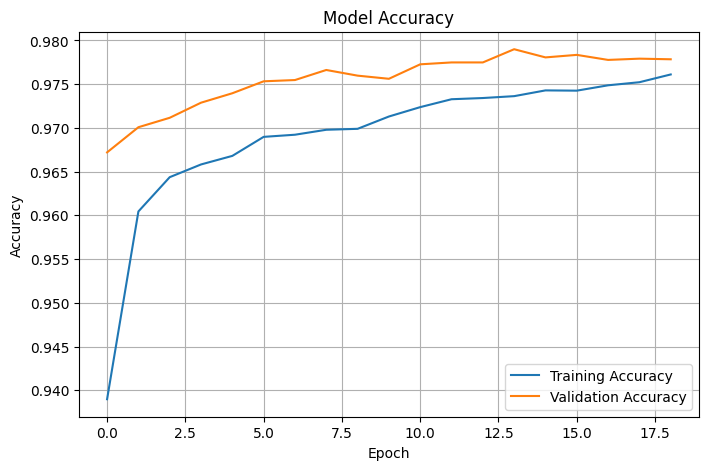

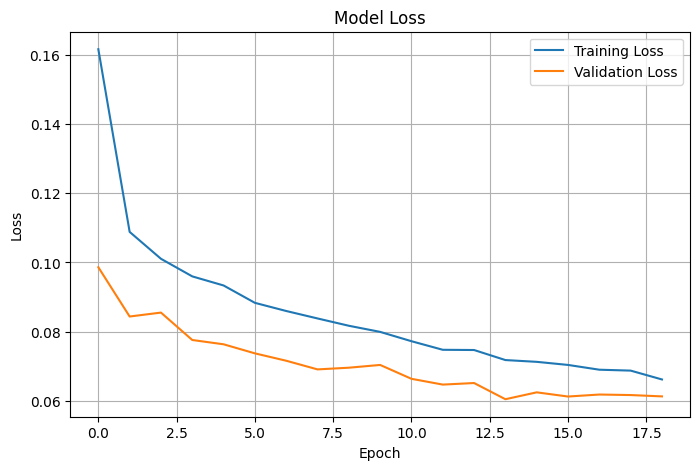

In [16]:
history_dict = history.history
print(history_dict.keys())

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 40
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback for fine-tuning
early_stopping_finetune = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_finetune = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[early_stopping_finetune]
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy after fine-tuning: {test_acc:.4f}")

# Save fine-tuned model
model.save("eye_model_finetuned.h5")

Epoch 1/30


2025-10-14 04:48:43.820223: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38535424 bytes after encountering the first element of size 38535424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-10-14 04:48:44.408976: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38535424 bytes after encountering the first element of size 38535424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1021/1021 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8996 - loss: 0.3125

2025-10-14 04:57:13.553558: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38535424 bytes after encountering the first element of size 38535424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1021/1021 ━━━━━━━━━━━━━━━━━━━━ 530s 500ms/step - accuracy: 0.9417 - loss: 0.1684 - val_accuracy: 0.9732 - val_loss: 0.0840
Epoch 2/30


...

2025-10-14 08:16:38.647451: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38535424 bytes after encountering the first element of size 38535424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1021/1021 ━━━━━━━━━━━━━━━━━━━━ 498s 488ms/step - accuracy: 0.9937 - loss: 0.0172 - val_accuracy: 0.9902 - val_loss: 0.0294
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 20.
  3/253 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 1.0000 - loss: 4.3378e-06

2025-10-14 08:16:46.258917: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 38535424 bytes after encountering the first element of size 38535424 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


253/253 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9781 - loss: 0.0705


Test accuracy after fine-tuning: 0.9781


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

print("Generating predictions on the test set...")
y_pred_probs = model.predict(test_ds)


y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = []
for images, labels in test_ds:
    if labels.ndim == 1 or labels.shape[-1] == 1:
        y_true.extend(labels.numpy().flatten())
    
    elif labels.ndim > 1 and labels.shape[-1] > 1:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    
    else:
        y_true.extend(labels.numpy())

y_true = np.array(y_true)

if len(y_pred) != len(y_true):
    print(f"\nWarning: Mismatch in lengths! True labels ({len(y_true)}) vs Predictions ({len(y_pred)})")
    min_len = min(len(y_pred), len(y_true))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    print(f"Truncated both to length: {min_len}")


target_names = ['Class 0 (Negative)', 'Class 1 (Positive)'] 
#              ['Closed Eyes',        'Open Eyes']

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

# Precision, Recall, F1-score, and Support
print(classification_report(y_true, y_pred, target_names=target_names))

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)


if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"\nTrue Positives (TP): {tp} (Correctly predicted Class 1)")
    print(f"True Negatives (TN): {tn} (Correctly predicted Class 0)")
    print(f"False Positives (FP): {fp} (Incorrectly predicted Class 1 / Type I Error)")
    print(f"False Negatives (FN): {fn} (Incorrectly predicted Class 0 / Type II Error)")

Generating predictions on the test set...
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Class 0 (Negative)       0.97      0.99      0.98      7777
Class 1 (Positive)       0.99      0.97      0.98      8362

          accuracy                           0.98     16139
         macro avg       0.98      0.98      0.98     16139
      weighted avg       0.98      0.98      0.98     16139


CONFUSION MATRIX
[[7689   88]
 [ 266 8096]]

True Positives (TP): 8096 (Correctly predicted Class 1)
True Negatives (TN): 7689 (Correctly predicted Class 0)
False Positives (FP): 88 (Incorrectly predicted Class 1 / Type I Error)
False Negatives (FN): 266 (Incorrectly predicted Class 0 / Type II Error)


2025-10-14 13:38:06.761001: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


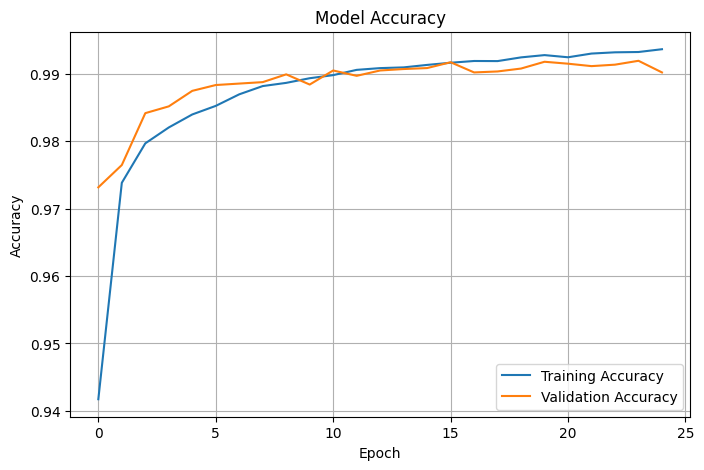

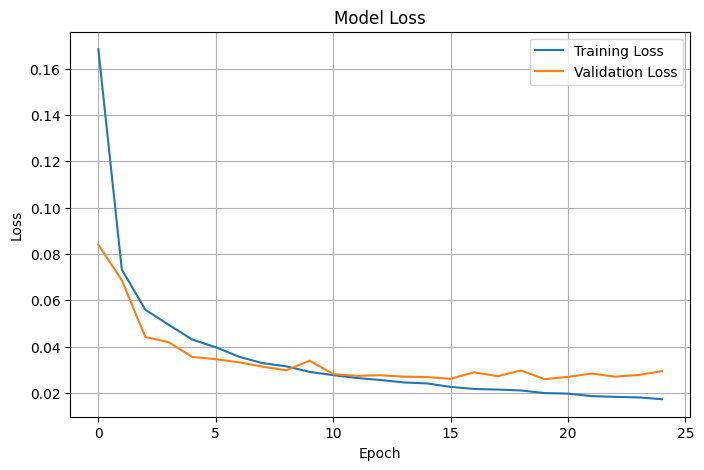

In [20]:
history_dict = history_finetune.history
print(history_dict.keys())

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()